<a href="https://colab.research.google.com/github/gicelamoyi/aprendizaje_automatico/blob/main/%20%20%20semana4/Regresion_lineal_vino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Preparación y organización de datos

In [2]:
import pandas as pd
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

TARGET = "quality"

print(df.shape)
df.info()
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()
print("Tamaño tras limpieza:", df.shape)

(1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides  

## 2. Exploración de los datos

In [4]:
print(df.describe())
print(df.corr()[TARGET].sort_values(ascending=False))

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1359.000000       1359.000000  1359.000000     1359.000000   
mean        8.310596          0.529478     0.272333        2.523400   
std         1.736990          0.183031     0.195537        1.352314   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.430000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1359.000000          1359.000000           1359.000000  1359.000000   
mean      0.088124            15.893304             46.825975     0.996709   
std       0.049377            10.447270             33.408946     0.001869   
min       0.012000             1.000000         

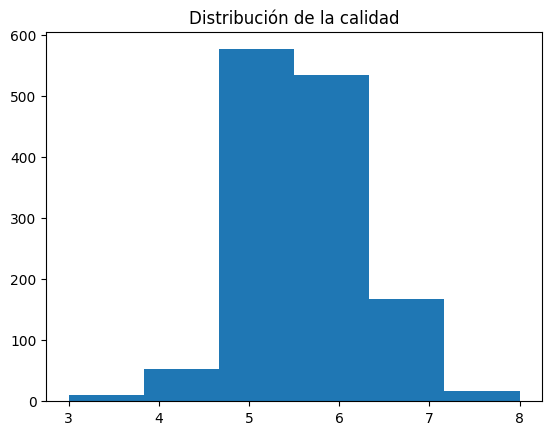

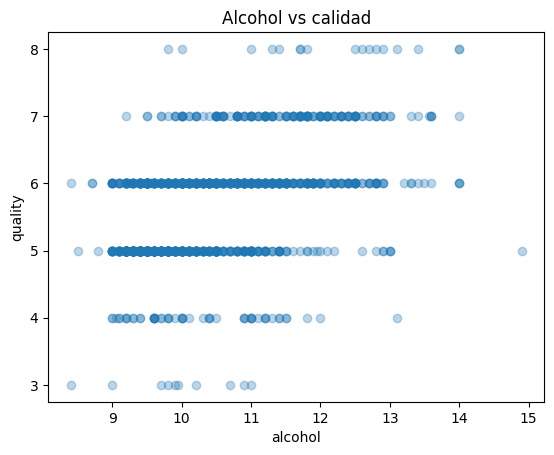

In [5]:
plt.figure()
plt.hist(df[TARGET], bins=6)
plt.title("Distribución de la calidad")
plt.show()

plt.figure()
plt.scatter(df["alcohol"], df[TARGET], alpha=0.3)
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.title("Alcohol vs calidad")
plt.show()

## 3. Modelado de datos

In [6]:
X = df.drop(columns=TARGET)
Y = df[TARGET]

X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

linear_regressor = linear_model.LinearRegression()
linear_regressor.fit(X_entrenamiento, Y_entrenamiento)

Y_predicha_de_entrenamiento = linear_regressor.predict(X_entrenamiento)
Y_predicha_de_prueba = linear_regressor.predict(X_prueba)

print("R2 entrenamiento:", r2_score(Y_entrenamiento, Y_predicha_de_entrenamiento))
print("R2 prueba:", r2_score(Y_prueba, Y_predicha_de_prueba))
print("MAE prueba:", mean_absolute_error(Y_prueba, Y_predicha_de_prueba))

coefs = pd.Series(linear_regressor.coef_, index=X.columns).sort_values()
print(coefs)

R2 entrenamiento: 0.351990097578611
R2 prueba: 0.3915360499058197
MAE prueba: 0.5041409053480708
chlorides               -2.210790
volatile acidity        -1.000799
pH                      -0.798708
citric acid             -0.098049
fixed acidity           -0.028794
residual sugar          -0.003832
total sulfur dioxide    -0.003713
free sulfur dioxide      0.004716
alcohol                  0.306154
sulphates                0.854602
density                 22.585222
dtype: float64


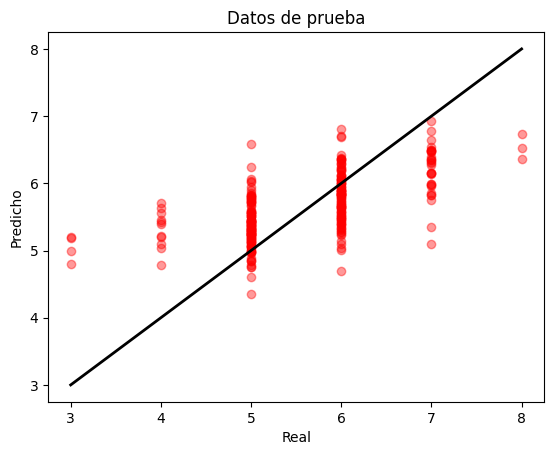

In [7]:
plt.figure()
plt.scatter(Y_prueba, Y_predicha_de_prueba, color='red', alpha=0.4)
plt.plot([Y_prueba.min(), Y_prueba.max()], [Y_prueba.min(), Y_prueba.max()], color='black', linewidth=2)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Datos de prueba")
plt.show()